<a href="https://colab.research.google.com/github/Riadislami/salient-object-detection/blob/main/salient_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
!git clone https://github.com/Riadislami/salient-object-detection.git
%cd /content/salient-object-detection/

Cloning into 'salient-object-detection'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/salient-object-detection


In [4]:
!unzip ECSSD.zip
!mkdir -p data/images/ data/masks
!cp ECSSD/images/* data/images
!cp ECSSD/masks/* data/masks

Archive:  ECSSD.zip
   creating: ECSSD/
   creating: ECSSD/images/
  inflating: ECSSD/images/0001.jpg   
  inflating: ECSSD/images/0002.jpg   
  inflating: ECSSD/images/0003.jpg   
  inflating: ECSSD/images/0004.jpg   
  inflating: ECSSD/images/0005.jpg   
  inflating: ECSSD/images/0006.jpg   
  inflating: ECSSD/images/0007.jpg   
  inflating: ECSSD/images/0008.jpg   
  inflating: ECSSD/images/0009.jpg   
  inflating: ECSSD/images/0010.jpg   
  inflating: ECSSD/images/0011.jpg   
  inflating: ECSSD/images/0012.jpg   
  inflating: ECSSD/images/0013.jpg   
  inflating: ECSSD/images/0014.jpg   
  inflating: ECSSD/images/0015.jpg   
  inflating: ECSSD/images/0016.jpg   
  inflating: ECSSD/images/0017.jpg   
  inflating: ECSSD/images/0018.jpg   
  inflating: ECSSD/images/0019.jpg   
  inflating: ECSSD/images/0020.jpg   
  inflating: ECSSD/images/0021.jpg   
  inflating: ECSSD/images/0022.jpg   
  inflating: ECSSD/images/0023.jpg   
  inflating: ECSSD/images/0024.jpg   
  inflating: ECSSD/im

In [5]:
!rm -f ECSSD.zip
!rm -rf ECSSD

In [6]:
import os
import cv2
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn

In [7]:
class SODDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        image = image / 255.0

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask, (224, 224))
        mask = mask / 255.0

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

In [8]:
dataset = SODDataset(
    img_dir="data/images",
    mask_dir="data/masks"
)

print("Dataset size:", len(dataset))

Dataset size: 1000


In [9]:
img, mask = dataset[0]

print(img.shape)
print(mask.shape)

torch.Size([3, 224, 224])
torch.Size([1, 224, 224])


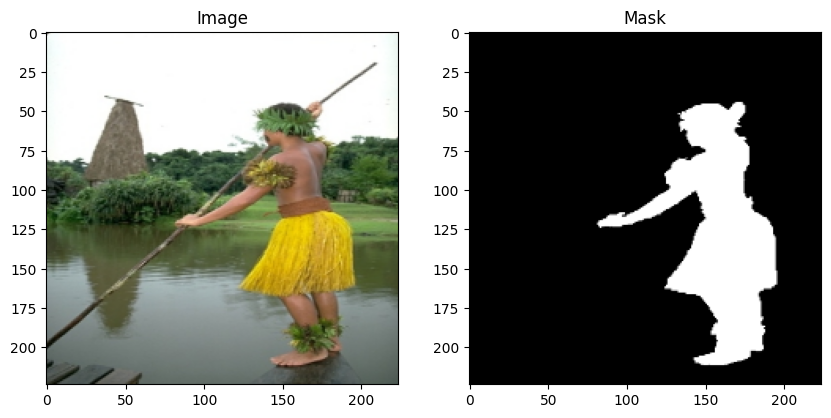

In [10]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Mask")

plt.show()

In [18]:
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Train: 700
Validation: 150
Test: 150


In [19]:
train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
val_loader = DataLoader(val_data, batch_size=8, shuffle=False)
test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

In [20]:
class SODModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [21]:
model = SODModel()

x = torch.randn(1, 3, 224, 224)
y = model(x)

print(y.shape)

torch.Size([1, 1, 224, 224])


In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

model = SODModel().to(device)

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 30

Using: cpu


In [23]:
train_losses = []
val_losses = []

for epoch in range(epochs):

    # TRAIN
    model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            loss = criterion(preds, masks)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

torch.save(model.state_dict(), "sod_model.pth")

print("Model saved.")

Epoch [1/30] Train Loss: 0.5862 Val Loss: 0.5188
Epoch [2/30] Train Loss: 0.4620 Val Loss: 0.4970
Epoch [3/30] Train Loss: 0.4622 Val Loss: 0.4891
Epoch [4/30] Train Loss: 0.4552 Val Loss: 0.4920
Epoch [5/30] Train Loss: 0.4546 Val Loss: 0.4963
Epoch [6/30] Train Loss: 0.4498 Val Loss: 0.5127
Epoch [7/30] Train Loss: 0.4475 Val Loss: 0.5003
Epoch [8/30] Train Loss: 0.4415 Val Loss: 0.4807
Epoch [9/30] Train Loss: 0.4455 Val Loss: 0.5095
Epoch [10/30] Train Loss: 0.4462 Val Loss: 0.4927
Epoch [11/30] Train Loss: 0.4450 Val Loss: 0.4788
Epoch [12/30] Train Loss: 0.4401 Val Loss: 0.4923
Epoch [13/30] Train Loss: 0.4420 Val Loss: 0.4936
Epoch [14/30] Train Loss: 0.4407 Val Loss: 0.4811
Epoch [15/30] Train Loss: 0.4414 Val Loss: 0.4937
Epoch [16/30] Train Loss: 0.4421 Val Loss: 0.4872
Epoch [17/30] Train Loss: 0.4356 Val Loss: 0.4753
Epoch [18/30] Train Loss: 0.4383 Val Loss: 0.4800
Epoch [19/30] Train Loss: 0.4374 Val Loss: 0.4765
Epoch [20/30] Train Loss: 0.4371 Val Loss: 0.4688
Epoch [21

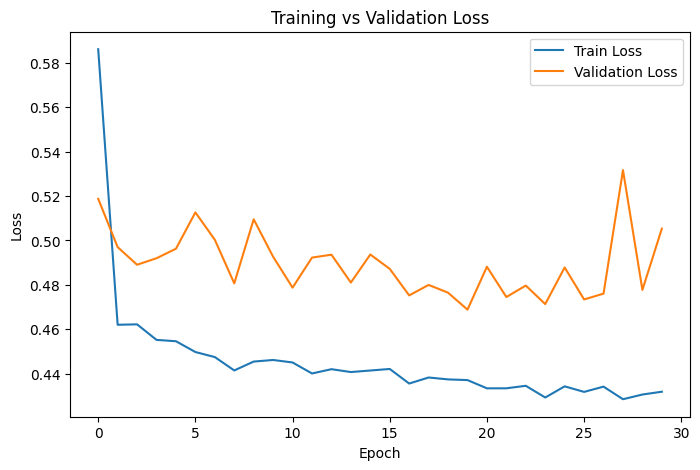

In [33]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [34]:
def calculate_metrics(pred, target):

    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    iou = intersection / (union + 1e-8)

    precision = intersection / (pred.sum() + 1e-8)

    recall = intersection / (target.sum() + 1e-8)

    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return (
        iou.item(),
        precision.item(),
        recall.item(),
        f1.item()
    )

In [35]:
model.eval()

total_iou = 0
total_precision = 0
total_recall = 0
total_f1 = 0

count = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        iou, precision, recall, f1 = calculate_metrics(
            preds,
            masks
        )

        total_iou += iou
        total_precision += precision
        total_recall += recall
        total_f1 += f1

        count += 1

print("IoU:", total_iou / count)
print("Precision:", total_precision / count)
print("Recall:", total_recall / count)
print("F1-score:", total_f1 / count)

IoU: 0.30266961925908137
Precision: 0.46939004408685786
Recall: 0.46025585814526204
F1-score: 0.45976557543403224


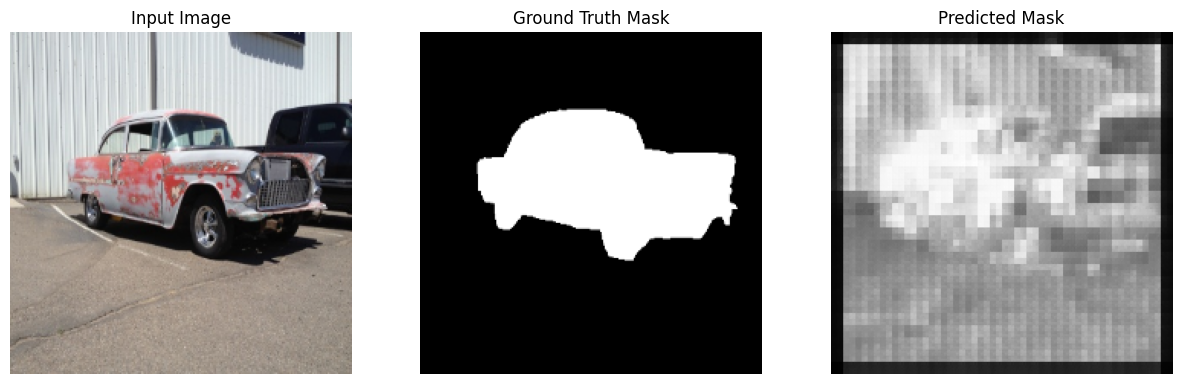

In [36]:
model.eval()

img, mask = test_data[0]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(device))

pred = pred.squeeze().cpu()
img_show = img.permute(1, 2, 0)
mask_show = mask.squeeze()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_show)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask_show, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

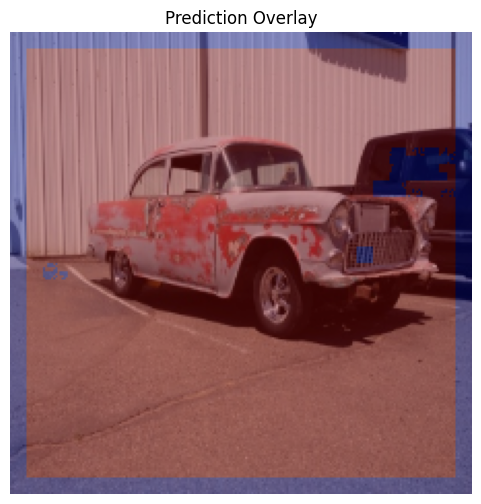

In [37]:
overlay = img_show.clone()

pred_binary = (pred > 0.3).float()

plt.figure(figsize=(6,6))
plt.imshow(img_show)
plt.imshow(pred_binary, cmap="jet", alpha=0.4)
plt.title("Prediction Overlay")
plt.axis("off")
plt.show()

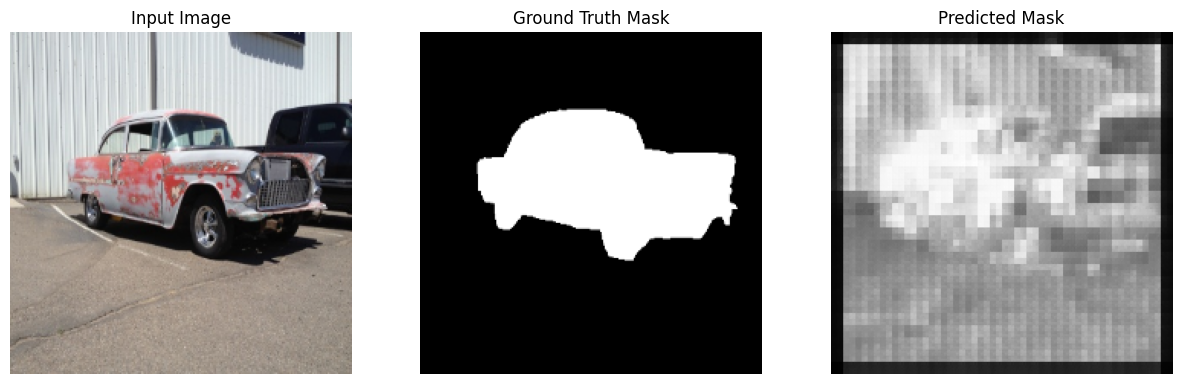

In [30]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_show)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask_show, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.savefig("prediction_results.png", bbox_inches="tight")
plt.show()

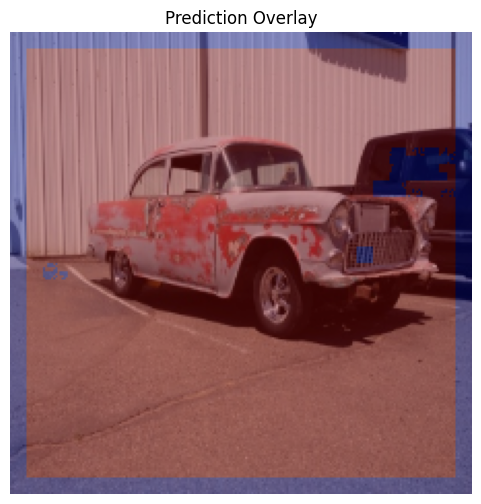

In [31]:
plt.figure(figsize=(6,6))
plt.imshow(img_show)
plt.imshow(pred_binary, cmap="jet", alpha=0.4)
plt.title("Prediction Overlay")
plt.axis("off")

plt.savefig("prediction_overlay.png", bbox_inches="tight")
plt.show()

In [32]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(model.state_dict(), "/content/drive/MyDrive/sod_model.pth")

Mounted at /content/drive
